<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/ML_EXPERIMENT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Load the Auto MPG dataset
try:
    df = pd.read_csv('auto-mpg.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'auto-mpg.csv' not found. Please upload the file to the Colab files sidebar.")

Dataset loaded successfully!


In [ ]:
# 2. Inspect and Clean Data
print("\n--- Dataset Info ---")
print(df.info())

# Handle missing values in horsepower column safely
if df['horsepower'].dtype == 'object':
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop any rows with missing values resulting from the conversion
df = df.dropna(subset=['horsepower', 'mpg'])


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [ ]:
# 3. Select Horsepower (X) and MPG (y)
X_raw = df['horsepower'].values
y = df['mpg'].values

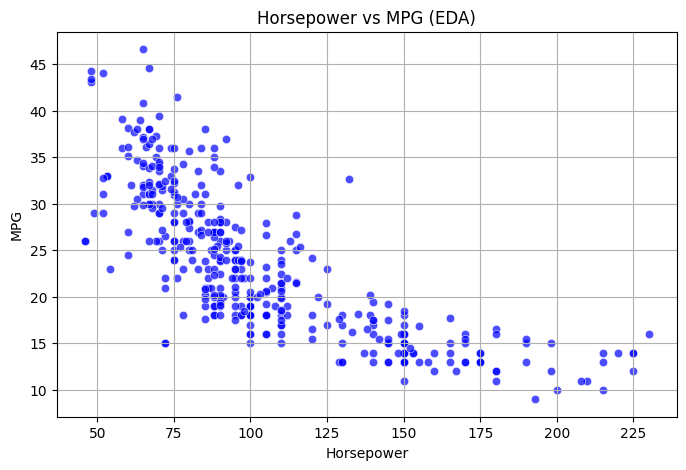

In [ ]:
# 4. Perform Exploratory Data Analysis (EDA) - Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_raw, y=y, color='blue', alpha=0.7)
plt.title('Horsepower vs MPG (EDA)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

In [ ]:
# 5. Add Bias Term & Compute OLS Weights using Matrix Form
# Formula: w = (X^T * X)^(-1) * X^T * y
X_matrix = np.vstack([np.ones(len(X_raw)), X_raw]).T  # Adds X0 = 1 column

# Calculating analytical weights
w = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y
intercept, slope = w[0], w[1]

print("\n--- OLS Regression Coefficients ---")
print(f"Intercept (w0): {intercept:.4f}")
print(f"Slope (w1): {slope:.4f}")
print(f"Regression Equation: y = {intercept:.4f} + ({slope:.4f}) * x")


--- OLS Regression Coefficients ---
Intercept (w0): 39.9359
Slope (w1): -0.1578
Regression Equation: y = 39.9359 + (-0.1578) * x


In [ ]:
# 6. Predict Values and Compute Residuals
y_pred = X_matrix @ w
residuals = y - y_pred

In [ ]:
# 7. Evaluate Performance Metrics (SSE, MSE, R²)
sse = np.sum(residuals ** 2)
mse = sse / len(y)
r2 = 1 - (sse / np.sum((y - np.mean(y)) ** 2))

print("\n--- Evaluation Metrics ---")
print(f"Sum of Squared Errors (SSE): {sse:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


--- Evaluation Metrics ---
Sum of Squared Errors (SSE): 9385.9159
Mean Squared Error (MSE): 23.9437
R-squared (R²): 0.6059


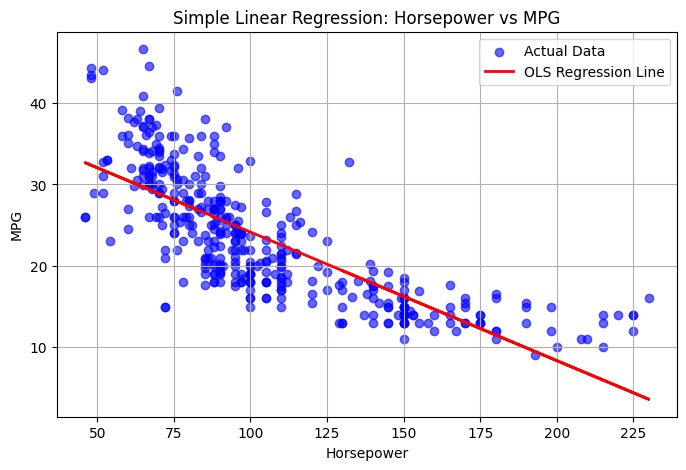

In [ ]:
# 8. Visualization: Regression Line Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_raw, y_pred, color='red', linewidth=2, label='OLS Regression Line')
plt.title('Simple Linear Regression: Horsepower vs MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.grid(True)
plt.show()

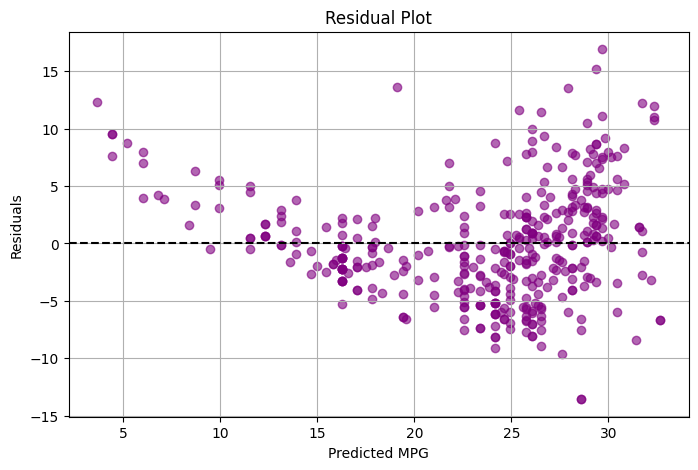

In [ ]:
# 9. Visualization: Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()